# **Customer Segmentation using Clustering Techniques**

### This dataset contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.
###The company mainly sells unique all-occasion gifts.
###Many customers of the company are wholesalers.

##**Objective: Segment the Customers based on RFM so that the company can target its customers efficiently where**

### **R (Recency): Number of days since last purchase**
### **F (Frequency): Number of transactions**
### **M (Monetary): Total amount of transactions (revenue contributed)**

In [3]:
# import required libraries for clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
retail = pd.read_csv('OnlineRetail.csv', sep=",", encoding="ISO-8859-1", header=0)

In [5]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
# shape of df

retail.shape

(50020, 8)

In [7]:
# df info

retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50020 entries, 0 to 50019
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    50020 non-null  object 
 1   StockCode    50020 non-null  object 
 2   Description  49878 non-null  object 
 3   Quantity     50020 non-null  int64  
 4   InvoiceDate  50020 non-null  object 
 5   UnitPrice    50020 non-null  float64
 6   CustomerID   32139 non-null  float64
 7   Country      50020 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.1+ MB


## **Data cleaning**

In [8]:
##percentage of missing values

df_null = round(100*(retail.isnull().sum())/len(retail), 2)
df_null

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.28
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,35.75
Country,0.00


In [9]:
# getting rid of rows having missing values

retail = retail.dropna()
retail.shape

(32139, 8)

In [10]:
# Changing the datatype of Customer Id

retail['CustomerID'] = retail['CustomerID'].astype(str)

In [11]:
# New Attribute : Monetary (or amount of transactions by that customer)

retail['Amount'] = retail['Quantity']*retail['UnitPrice']
rfm_m = retail.groupby('CustomerID')['Amount'].sum()
rfm_m = rfm_m.reset_index()
rfm_m

,CustomerID,Amount
0,12347.0,711.79
1,12348.0,892.80
2,12370.0,1868.02
3,12377.0,1001.52
4,12383.0,600.72
...,...,...
1034,18256.0,-50.10
1035,18259.0,376.30
1036,18260.0,787.77
1037,18269.0,138.90


In [12]:
# New Attribute : Frequency

rfm_f = retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
rfm_f.head()

,CustomerID,Frequency
0,12347.0,31
1,12348.0,17
2,12370.0,91
3,12377.0,43
4,12383.0,37


In [13]:
# Merging the two dfs

rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12347.0,711.79,31
1,12348.0,892.80,17
2,12370.0,1868.02,91
3,12377.0,1001.52,43
4,12383.0,600.72,37


In [14]:
# New Attribute : Recency (no. of days since previous purchase)

retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'],format='%d-%m-%Y %H:%M')
max_date = max(retail['InvoiceDate'])
max_date
retail['Diff'] = max_date - retail['InvoiceDate']
retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,39 days 06:57:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,39 days 06:57:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,39 days 06:57:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,39 days 06:57:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,39 days 06:57:00
...,...,...,...,...,...,...,...,...,...,...
50015,540543,20702,PINK PADDED MOBILE,4,2011-01-09 15:23:00,4.25,14395.0,United Kingdom,17.00,0 days 00:00:00
50016,540543,85152,HAND OVER THE CHOCOLATE SIGN,7,2011-01-09 15:23:00,2.10,14395.0,United Kingdom,14.70,0 days 00:00:00
50017,540543,22469,HEART OF WICKER SMALL,6,2011-01-09 15:23:00,1.65,14395.0,United Kingdom,9.90,0 days 00:00:00
50018,540543,22061,LARGE CAKE STAND HANGING STRAWBERY,2,2011-01-09 15:23:00,9.95,14395.0,United Kingdom,19.90,0 days 00:00:00


In [15]:
# computing recency of customer

rfm_p = retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
rfm_p

,CustomerID,Diff
0,12347.0,33 days 00:26:00
1,12348.0,23 days 20:14:00
2,12370.0,23 days 05:45:00
3,12377.0,20 days 05:46:00
4,12383.0,18 days 00:55:00
...,...,...
1034,18256.0,20 days 06:56:00
1035,18259.0,32 days 01:45:00
1036,18260.0,0 days 00:41:00
1037,18269.0,23 days 23:44:00


In [16]:
# extracting number of days only

rfm_p['Diff'] = rfm_p['Diff'].dt.days
rfm_p

,CustomerID,Diff
0,12347.0,33
1,12348.0,23
2,12370.0,23
3,12377.0,20
4,12383.0,18
...,...,...
1034,18256.0,20
1035,18259.0,32
1036,18260.0,0
1037,18269.0,23


In [17]:
# merging the dataframes to get the final dataframe

rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
rfm

,CustomerID,Amount,Frequency,Recency
0,12347.0,711.79,31,33
1,12348.0,892.80,17,23
2,12370.0,1868.02,91,23
3,12377.0,1001.52,43,20
4,12383.0,600.72,37,18
...,...,...,...,...
1034,18256.0,-50.10,4,20
1035,18259.0,376.30,7,32
1036,18260.0,787.77,37,0
1037,18269.0,138.90,8,23


Text(0.5, 0, 'Attributes')

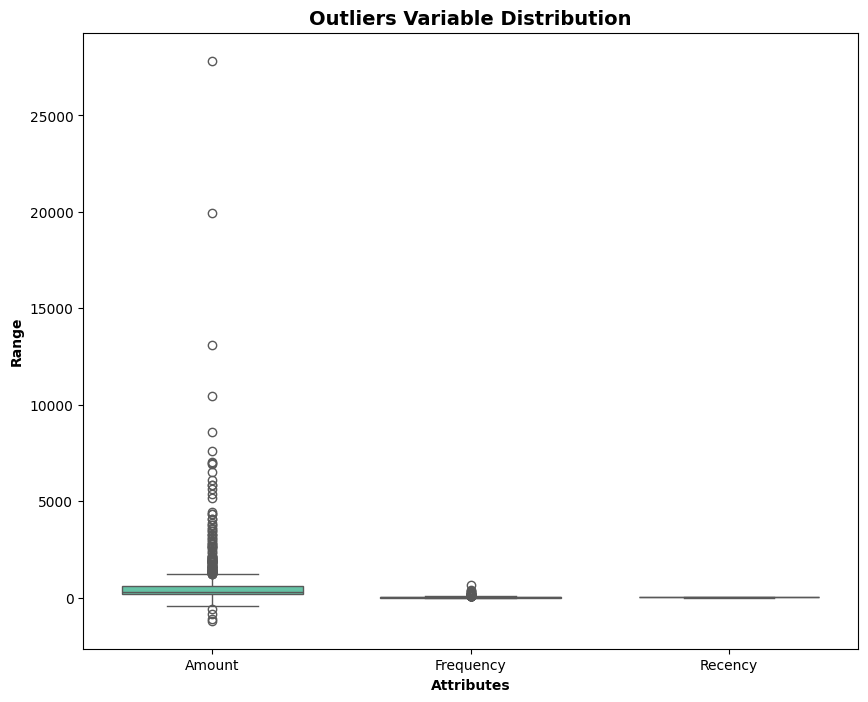

In [18]:
# Outlier Analysis

attributes = ['Amount','Frequency','Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = rfm[attributes], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')

In [19]:
# Removing outliers for Amount. (using the IQR Method)
Q1 = rfm.Amount.quantile(0.05)
Q3 = rfm.Amount.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Amount >= Q1 - 1.5*IQR) & (rfm.Amount <= Q3 + 1.5*IQR)]

# Removing outliers for Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5*IQR) & (rfm.Recency <= Q3 + 1.5*IQR)]

# Removing outliers for Frequency
Q1 = rfm.Frequency.quantile(0.05)
Q3 = rfm.Frequency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5*IQR) & (rfm.Frequency <= Q3 + 1.5*IQR)]

# Scaling the features

In [20]:
rfm_df = rfm[['Amount', 'Frequency', 'Recency']]
scaler = StandardScaler()
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape

(1019, 3)

In [21]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['Amount', 'Frequency', 'Recency']
rfm_df_scaled

,Amount,Frequency,Recency
0,0.361720,0.101700,0.814420
1,0.657097,-0.372279,-0.014231
2,2.248486,2.133035,-0.014231
3,0.834509,0.507967,-0.262826
4,0.180473,0.304833,-0.428557
...,...,...,...
1014,-0.881552,-0.812401,-0.262826
1015,-0.185741,-0.710834,0.731555
1016,0.485706,0.304833,-1.920128
1017,-0.573137,-0.676979,-0.014231


In [22]:
rfm_df_scaled

,Amount,Frequency,Recency
0,0.361720,0.101700,0.814420
1,0.657097,-0.372279,-0.014231
2,2.248486,2.133035,-0.014231
3,0.834509,0.507967,-0.262826
4,0.180473,0.304833,-0.428557
...,...,...,...
1014,-0.881552,-0.812401,-0.262826
1015,-0.185741,-0.710834,0.731555
1016,0.485706,0.304833,-1.920128
1017,-0.573137,-0.676979,-0.014231


##**Model Building**

###**1.  K-Means Clustering**


In [23]:
model0 = KMeans(n_clusters=4, max_iter=50)
model0.fit(rfm_df_scaled)

KMeans(max_iter=50, n_clusters=4)

In [24]:
model0.labels_

array([1, 1, 2, ..., 3, 1, 3], dtype=int32)

In [25]:
set(model0.labels_)

{np.int32(0), np.int32(1), np.int32(2), np.int32(3)}

# Elbow Curve to get the right number of Clusters

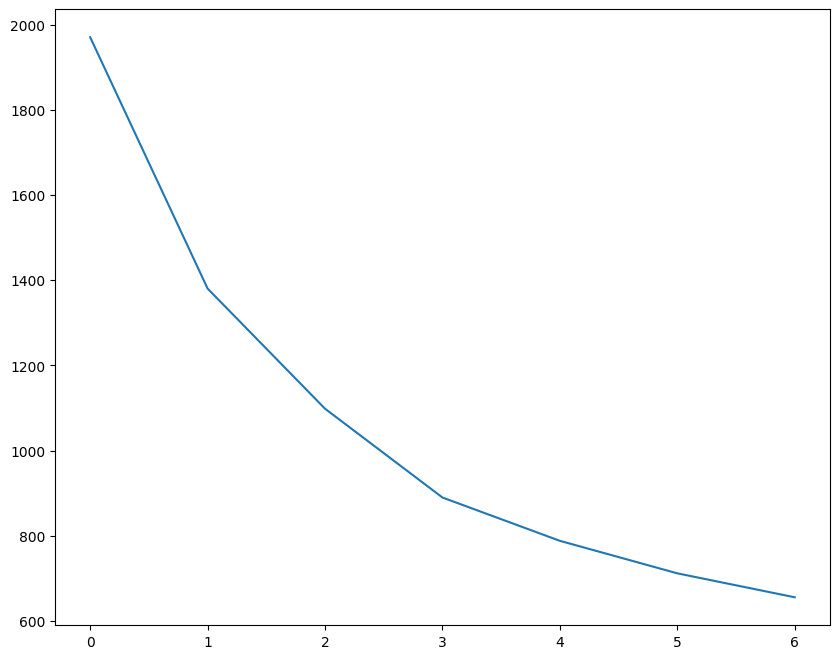

In [26]:
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(rfm_df_scaled)

    ssd.append(kmeans.inertia_)

# plot the SSDs for each n_clusters
plt.plot(ssd)

In [27]:
# final model with k=3
model0 = KMeans(n_clusters=3, max_iter=50)
model0.fit(rfm_df_scaled)

KMeans(max_iter=50, n_clusters=3)

In [28]:
model0.labels_

array([0, 0, 1, ..., 2, 0, 2], dtype=int32)

In [29]:
# assign the label
rfm['Cluster_Id'] = model0.labels_
rfm

,CustomerID,Amount,Frequency,Recency,Cluster_Id
0,12347.0,711.79,31,33,0
1,12348.0,892.80,17,23,0
2,12370.0,1868.02,91,23,1
3,12377.0,1001.52,43,20,0
4,12383.0,600.72,37,18,0
...,...,...,...,...,...
1034,18256.0,-50.10,4,20,0
1035,18259.0,376.30,7,32,0
1036,18260.0,787.77,37,0,2
1037,18269.0,138.90,8,23,0


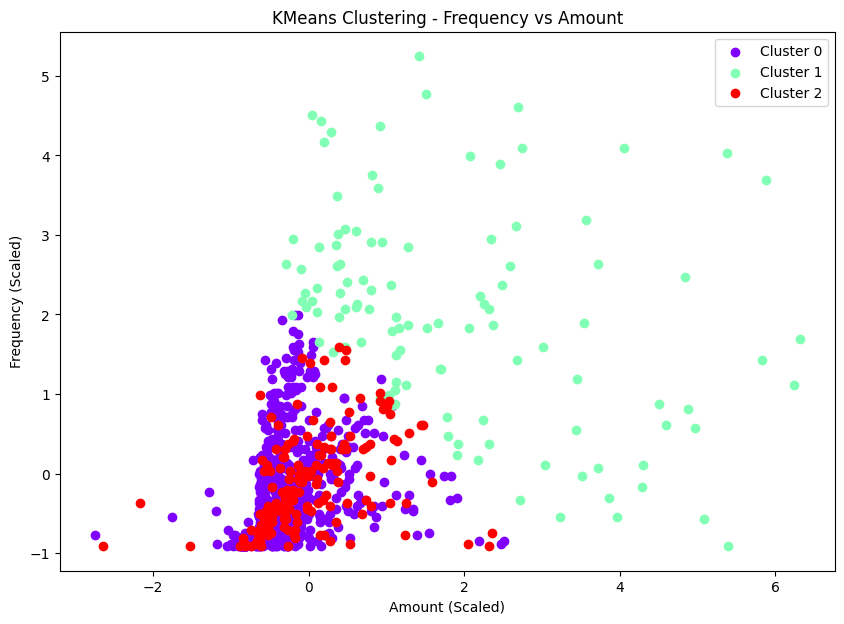

In [61]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model0.labels_)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[model0.labels_ == label]
    plt.scatter(subset['Amount'], subset['Frequency'], color=colors[i], label=f'Cluster {label}')

plt.xlabel('Amount (Scaled)')
plt.ylabel('Frequency (Scaled)')
plt.title('KMeans Clustering - Frequency vs Amount')
plt.legend()
plt.show()

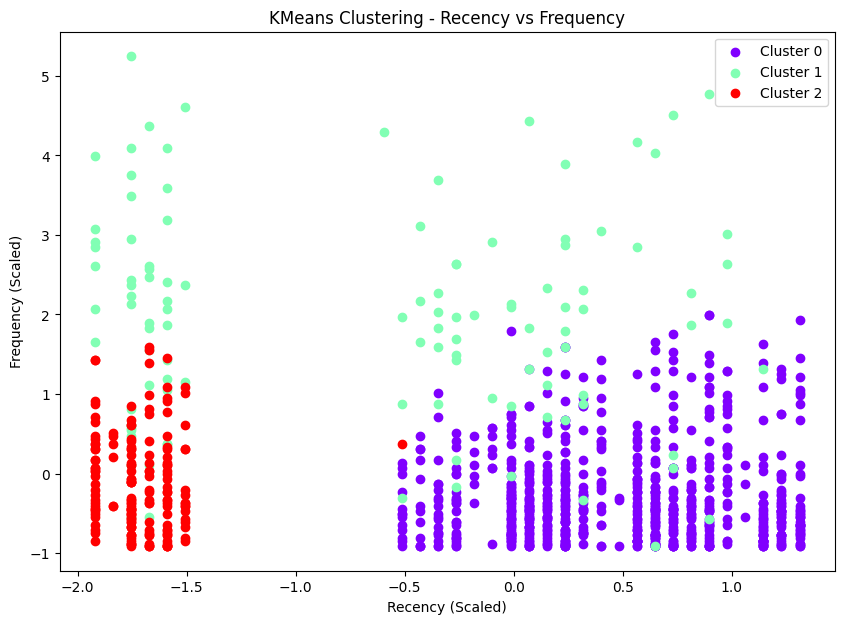

In [62]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model0.labels_)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[model0.labels_ == label]
    plt.scatter(subset['Recency'], subset['Frequency'], color=colors[i], label=f'Cluster {label}')

plt.xlabel('Recency (Scaled)')
plt.ylabel('Frequency (Scaled)')
plt.title('KMeans Clustering - Recency vs Frequency')
plt.legend()
plt.show()

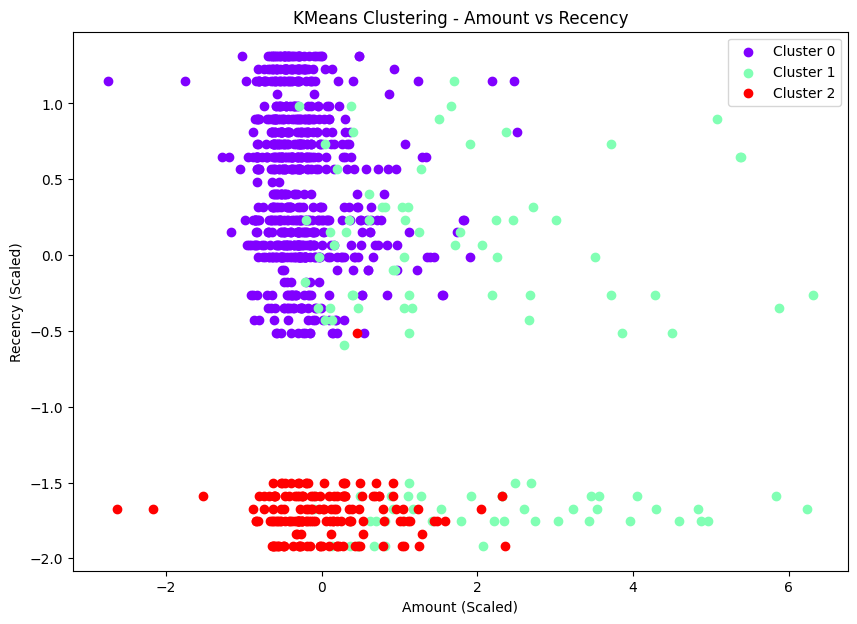

In [63]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model0.labels_)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[model0.labels_ == label]
    plt.scatter(subset['Amount'], subset['Recency'], color=colors[i], label=f'Cluster {label}')

plt.xlabel('Amount (Scaled)')
plt.ylabel('Recency (Scaled)')
plt.title('KMeans Clustering - Amount vs Recency')
plt.legend()
plt.show()


###**KMeans Clustering(model0) - Cluster Descriptions**


#### **Cluster 0 (Medium Frequency, Medium Amount, Recent Purchasers)**
*   **Recency:** These customers have made recent purchases, indicating they might be actively engaged.
*   **Frequency:** They purchase with moderate frequency.
*   **Monetary (Amount):** They contribute a medium amount of revenue.

This segment represents a good base of regular customers who are still active and spend a moderate amount. They could be targeted with loyalty programs or personalized recommendations to encourage continued engagement and higher spending.

#### **Cluster 1:Low Value Customers (Low Frequency, Low Amount, Less Recent Purchasers)**
*   **Recency:** These customers have not made recent purchases, suggesting they might be becoming inactive or dormant.
*   **Frequency:** Their purchase frequency is low.
*   **Monetary (Amount):** They contribute the least amount of revenue.

This segment includes customers who are less engaged and spend less. Strategies for this group could focus on re-engagement campaigns, special offers to entice them back, or even understanding why they've become less active.

#### **Cluster 2: High-Value Customers (High Frequency, High Amount, Recent Purchasers)**
*   **Recency:** These customers have made very recent purchases, indicating high current engagement.
*   **Frequency:** They purchase very frequently.
*   **Monetary (Amount):** They contribute the highest amount of revenue.

This segment represents the most valuable customers. They should be prioritized for exclusive offers, premium services, and personalized communication to maintain their loyalty and maximize their lifetime value. They are likely to be your 'champions'.

###**2.Hierarchial Clustering**

In [34]:
from sklearn.cluster import AgglomerativeClustering

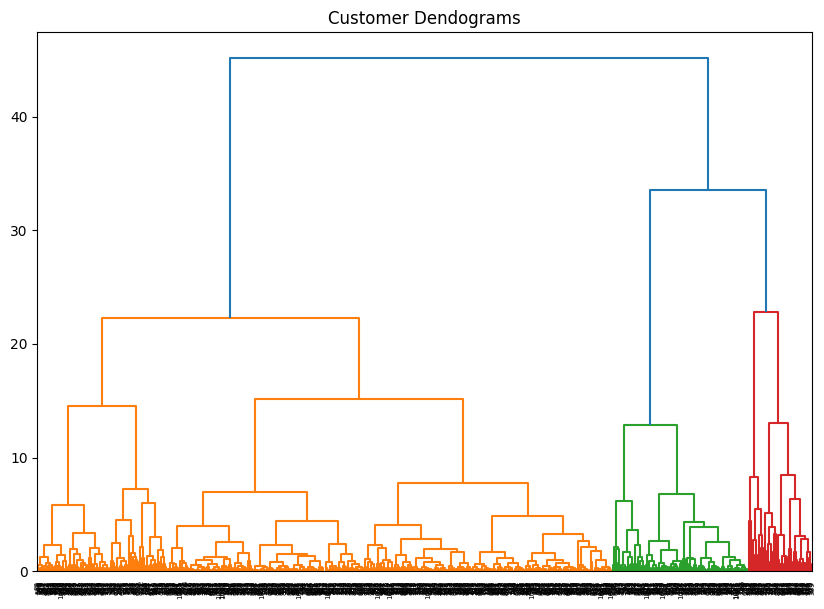

In [35]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Customer Dendograms")
dend = shc.dendrogram(shc.linkage(rfm_df_scaled, method='ward'))

###From the dendogram , we can see that if a horizontal line is drawn through the longest vertical line , it can cut 3 such vertical lines which means 3 clusters should be ideal.

In [36]:
model1 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_ = model1.fit_predict(rfm_df_scaled)

In [37]:
labels_

array([1, 1, 1, ..., 2, 1, 2])

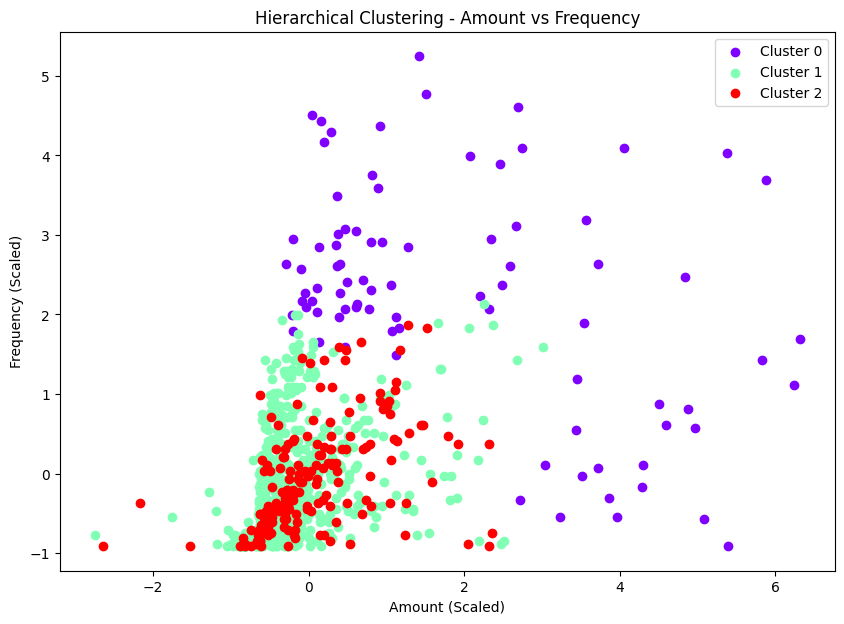

In [64]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model1.labels_)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[model1.labels_ == label]
    plt.scatter(subset['Amount'], subset['Frequency'], color=colors[i], label=f'Cluster {label}')

plt.xlabel('Amount (Scaled)')
plt.ylabel('Frequency (Scaled)')
plt.title('Hierarchical Clustering - Amount vs Frequency')
plt.legend()
plt.show()

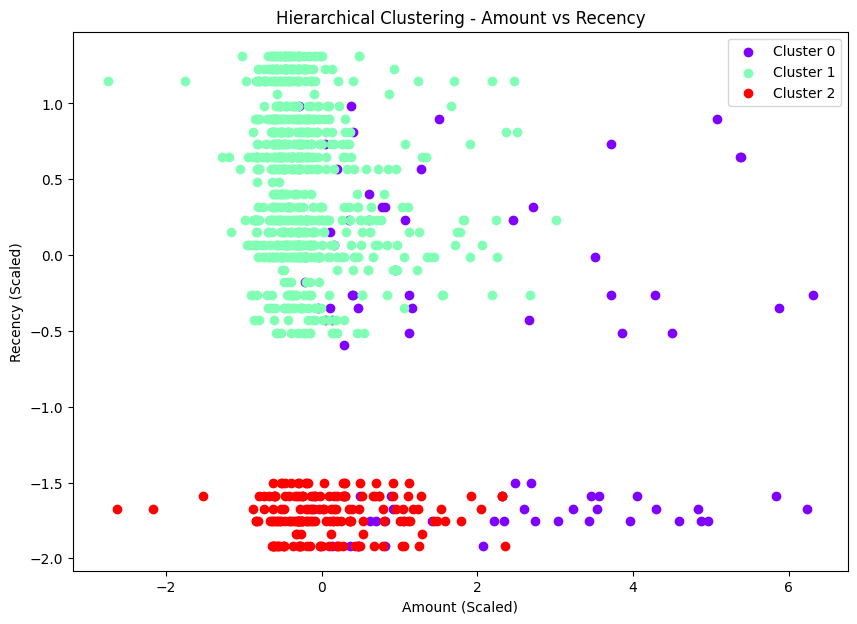

In [65]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model1.labels_)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[model1.labels_ == label]
    plt.scatter(subset['Amount'], subset['Recency'], color=colors[i], label=f'Cluster {label}')

plt.xlabel('Amount (Scaled)')
plt.ylabel('Recency (Scaled)')
plt.title('Hierarchical Clustering - Amount vs Recency')
plt.legend()
plt.show()

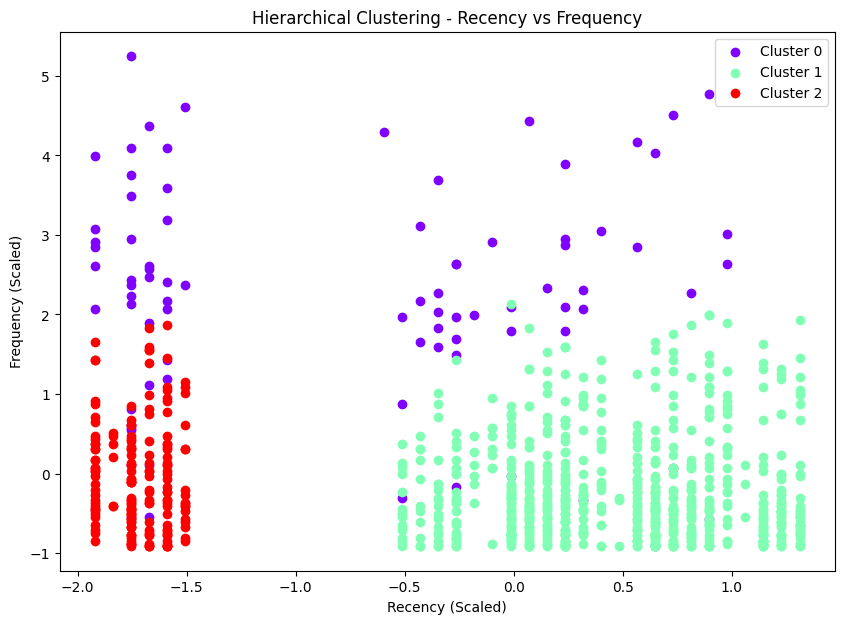

In [66]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model1.labels_)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[model1.labels_ == label]
    plt.scatter(subset['Recency'], subset['Frequency'], color=colors[i], label=f'Cluster {label}')

plt.xlabel('Recency (Scaled)')
plt.ylabel('Frequency (Scaled)')
plt.title('Hierarchical Clustering - Recency vs Frequency')
plt.legend()
plt.show()

### **Hierarchical Clustering (model1) - Cluster Descriptions**

Based on the scatter plots generated from the Hierarchical Clustering ('model1') results, we can observe the following characteristics for each cluster:

#### **Cluster 0 :Low Value Customers**
*   **Recency:** These customers generally have higher recency values, meaning they haven't made purchases recently.
*   **Frequency:** Their purchase frequency is low.
*   **Monetary (Amount):** They contribute a lower amount of revenue.

This cluster largely aligns with the 'Low Value' segment, indicating customers who are less engaged and spend less.

#### **Cluster 1 : High-Value/Recent Customers**
*   **Recency:** These customers show very low recency values, indicating they have made purchases very recently.
*   **Frequency:** Their purchase frequency is generally high.
*   **Monetary (Amount):** They tend to have higher monetary values, indicating significant spending.

This cluster represents highly active and valuable customers who are frequent and recent purchasers, contributing significantly to revenue.

#### **Cluster 2 : Regular Spenders**
*   **Recency:** This group shows a moderate range of recency, indicating they purchase somewhat regularly but not as frequently as Cluster 1.
*   **Frequency:** Their purchase frequency is in the mid-range.
*   **Monetary (Amount):** They contribute a moderate amount of revenue.

This cluster represents a segment of regular customers who are moderately engaged and contribute a steady amount of sales.

##**3.DBSCAN**

In [41]:
from sklearn.cluster import DBSCAN

In [42]:
model2 = DBSCAN(eps=1 , min_samples=3)
model2.fit(rfm_df_scaled)

DBSCAN(eps=1, min_samples=3)

In [43]:
np.unique(model2.labels_)

array([-1,  0,  1,  2])

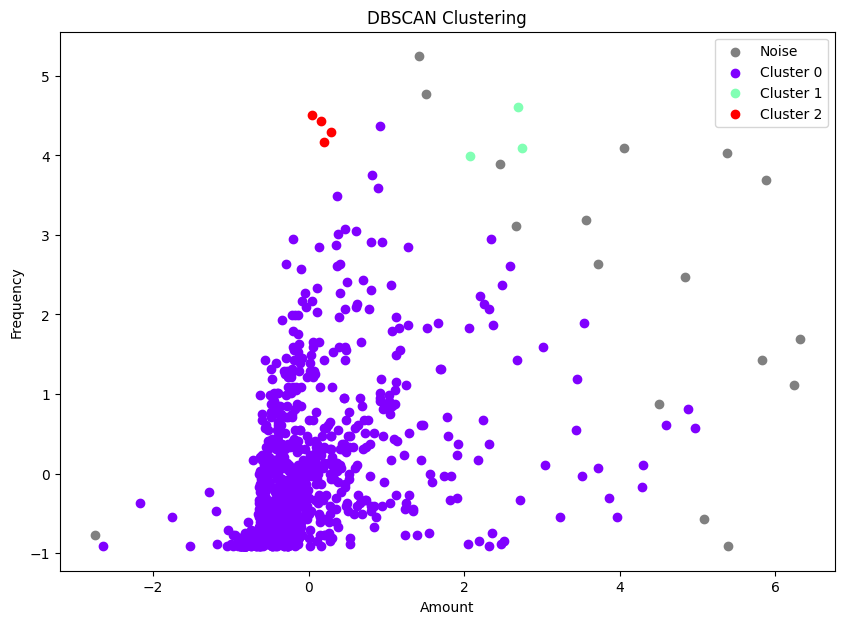

In [67]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model2.labels_)

actual_clusters = [l for l in unique_labels if l != -1]
colors_map = plt.cm.rainbow(np.linspace(0, 1, len(actual_clusters)))
color_dict = {label: colors_map[i] for i, label in enumerate(actual_clusters)}
color_dict[-1] = 'grey' # assigning grey to noise

for label in unique_labels:
    subset = rfm_df_scaled[model2.labels_ == label]
    if label == -1:
        plt.scatter(subset['Amount'], subset['Frequency'], color=color_dict[label], label='Noise')
    else:
        plt.scatter(subset['Amount'], subset['Frequency'], color=color_dict[label], label=f'Cluster {label}')

plt.title('DBSCAN Clustering')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

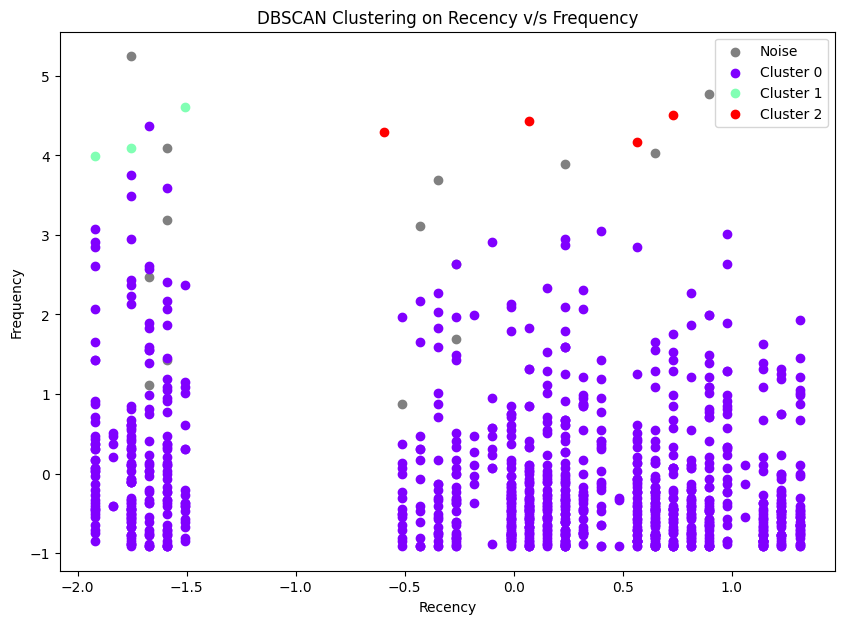

In [68]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model2.labels_)

actual_clusters = [l for l in unique_labels if l != -1]
colors_map = plt.cm.rainbow(np.linspace(0, 1, len(actual_clusters)))
color_dict = {label: colors_map[i] for i, label in enumerate(actual_clusters)}
color_dict[-1] = 'grey' # assigning grey to noise

for label in unique_labels:
    subset = rfm_df_scaled[model2.labels_ == label]
    if label == -1:
        plt.scatter(subset['Recency'], subset['Frequency'], color=color_dict[label], label='Noise')
    else:
        plt.scatter(subset['Recency'], subset['Frequency'], color=color_dict[label], label=f'Cluster {label}')

plt.title('DBSCAN Clustering on Recency v/s Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend()
plt.show()

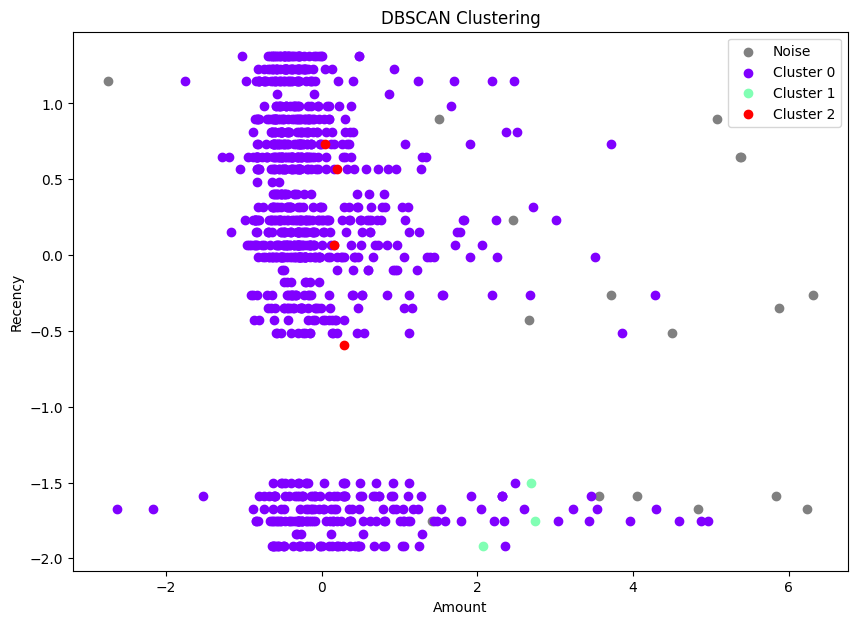

In [69]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(model2.labels_)

actual_clusters = [l for l in unique_labels if l != -1]
colors_map = plt.cm.rainbow(np.linspace(0, 1, len(actual_clusters)))
color_dict = {label: colors_map[i] for i, label in enumerate(actual_clusters)}
color_dict[-1] = 'grey' # assigning grey to noise

for label in unique_labels:
    subset = rfm_df_scaled[model2.labels_ == label]
    if label == -1:
        plt.scatter(subset['Amount'], subset['Recency'], color=color_dict[label], label='Noise')
    else:
        plt.scatter(subset['Amount'], subset['Recency'], color=color_dict[label], label=f'Cluster {label}')

plt.title('DBSCAN Clustering')
plt.xlabel('Amount')
plt.ylabel('Recency')
plt.legend()
plt.show()

### **DBSCAN (model2) - Cluster Descriptions**

Based on the scatter plots for 'model2', which identified 3 clusters and noise points, here are the descriptions:

#### **Cluster 0 (DBSCAN model2): General Customer Base**
*   This appears to be the largest cluster, representing the majority of customers.
*   They generally have moderate 'Amount' and 'Frequency' and higher 'Recency' (meaning they haven't purchased very recently compared to other active groups).

This cluster forms the core customer base with average purchasing behavior.

#### **Cluster 1 (DBSCAN model2): Engaged Purchasers**
*   These customers show a tendency towards lower 'Recency' (more recent purchases) and higher 'Frequency'.
*   Their 'Amount' is generally moderate to high.

This segment represents customers who are more actively engaged with recent and frequent purchases.

#### **Cluster 2 (DBSCAN model2): Less Frequent/Recent**
*   This cluster seems to consist of customers with lower 'Frequency' and higher 'Recency'.
*   Their 'Amount' tends to be on the lower side.

This segment might represent customers who purchase less often and are less recently engaged.

#### **Noise (-1) (DBSCAN model2): Outliers/Unique Cases**
*   These points do not belong to any distinct cluster identified by DBSCAN and are considered outliers.
*   They could represent highly unique purchasing behaviors, such as extremely high spending, very infrequent but large purchases, or customers with unusual patterns that don't fit the general groups.

##**4.Gaussian Mixture Model**

In [51]:
from sklearn.mixture import GaussianMixture

In [52]:
model4 = GaussianMixture(n_components=3)
labels = model4.fit_predict(rfm_df_scaled)

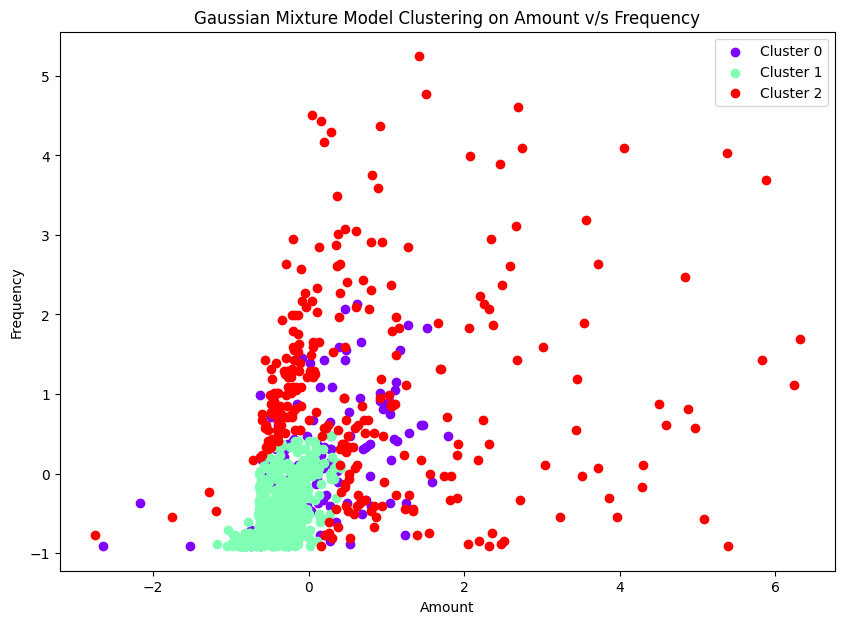

In [70]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[labels == label]
    plt.scatter(subset['Amount'], subset['Frequency'], color=colors[i], label=f'Cluster {label}')

plt.title('Gaussian Mixture Model Clustering on Amount v/s Frequency')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

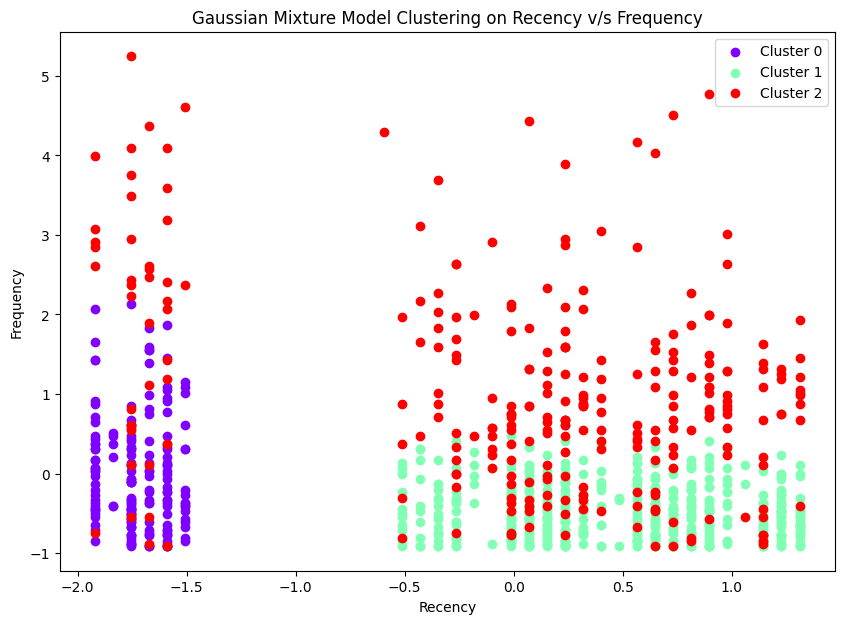

In [71]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[labels == label]
    plt.scatter(subset['Recency'], subset['Frequency'], color=colors[i], label=f'Cluster {label}')

plt.title('Gaussian Mixture Model Clustering on Recency v/s Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend()
plt.show()

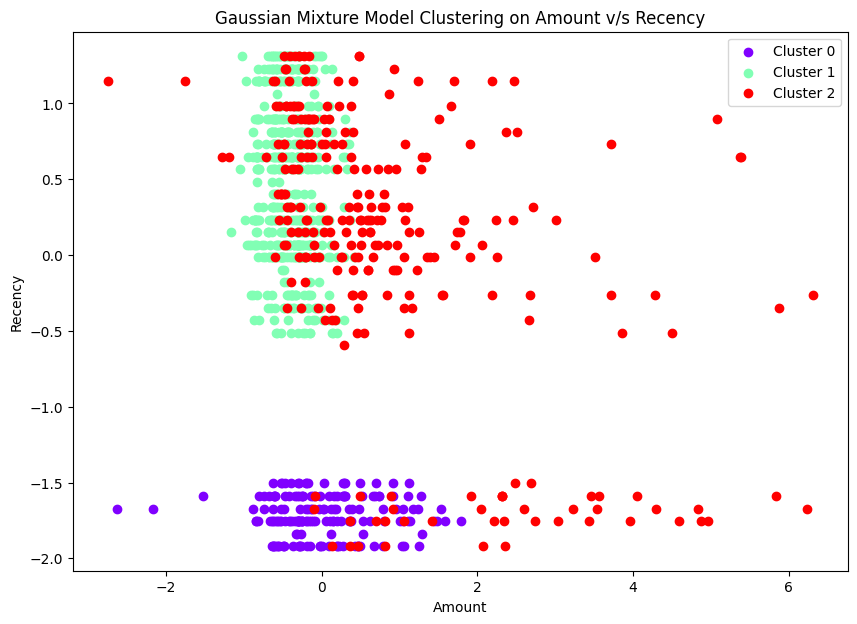

In [72]:
plt.figure(figsize=(10,7))
unique_labels = np.unique(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    subset = rfm_df_scaled[labels == label]
    plt.scatter(subset['Amount'], subset['Recency'], color=colors[i], label=f'Cluster {label}')

plt.title('Gaussian Mixture Model Clustering on Amount v/s Recency')
plt.xlabel('Amount')
plt.ylabel('Recency')
plt.legend()
plt.show()

### **Gaussian Mixture Model (model4) - Cluster Descriptions**

Based on the scatter plots generated from the Gaussian Mixture Model (`model4`) results, which identified 3 clusters, here are the descriptions:

#### **Cluster 0 (GMM model4): High-Value, Recent, and Frequent Customers**
*   **Recency:** These customers have very low recency values, indicating they have purchased very recently.
*   **Frequency:** They exhibit high frequency of purchases.
*   **Monetary (Amount):** They contribute a significantly high amount of revenue.

This cluster represents the most valuable and active customers. They are highly engaged and are critical for revenue. Strategies should focus on retention and premium offerings.

#### **Cluster 1 (GMM model4): Low-Value, Less Frequent, and Older Customers**
*   **Recency:** These customers have high recency values, meaning it's been a long time since their last purchase.
*   **Frequency:** Their purchase frequency is low.
*   **Monetary (Amount):** They contribute a relatively low amount of revenue.

This cluster represents customers who are less engaged, make fewer purchases, and haven't bought recently. This segment might require re-engagement campaigns or specific promotions to reactivate them.

#### **Cluster 2 (GMM model4): Moderate Spenders with Average Engagement**
*   **Recency:** This group shows moderate recency, indicating they purchase somewhat regularly but are not as recent as Cluster 0.
*   **Frequency:** Their purchase frequency is in the mid-range.
*   **Monetary (Amount):** They contribute a moderate amount of revenue.

This cluster represents a solid base of customers with average engagement and spending. They could be targeted with personalized recommendations to increase their frequency and monetary value.

##**Conclusion**



### **Recommended Model: Gaussian Mixture Model (GMM)**

####The Gaussian Mixture Model ('model4') provides well-defined and actionable customer segments that can be directly translated into targeted business strategies. It offers a good balance of interpretability and flexibility in clustering.Compared to other techniques , its clustering is probabilistic in nature and it can handle overlapping clusters well.

### **Business Strategies Based on GMM Clusters**

#### **Cluster 0 : High-Value, Recent, and Frequent Customers**

*   **Characteristics:** It is essential to treat thee customers as Gods.They buy recently, frequently, and spend a lot. They are crucial for your business.
*   **Business Strategy:**
    *   **Retention Programs:** Reward their loyalty with exclusive offers, early access to new products, or premium services.
    *   **Personalized Upselling/Cross-selling:** Recommend higher-value items or complementary products based on their past purchases.
    *   **Feedback & Advocacy:** Engage them for testimonials, reviews, and referrals. They can be powerful brand advocates.
    *   **VIP Treatment:** Provide dedicated customer support or special recognition.

#### **Cluster 1 : Low-Value, Less Frequent, and Older Customers**

*   **Characteristics:** These customers haven't purchased in a while, buy infrequently, and spend less. They might be at risk of churning or are already dormant.
*   **Business Strategy:**
    *   **Re-engagement Campaigns:** Send targeted emails with special discounts, incentives, or reminders about products they might like.
    *   **Win-Back Offers:** Provide compelling reasons to return, such as significant discounts or free shipping for their next purchase.
    *   **Feedback Collection:** Survey them to understand why they became inactive and identify pain points.
    *   **Cost-Benefit Analysis:** Determine if the cost of re-engaging them outweighs potential future revenue. Some might be better to let go if efforts are too high.

#### **Cluster 2: Moderate Spenders with Average Engagement**

*   **Characteristics:** This group shows average purchasing behavior – they buy somewhat regularly and contribute a moderate amount.
*   **Business Strategy:**
    *   **Growth & Nurturing:** Encourage them to move into the 'High-Value' segment.
    *   **Personalized Recommendations:** Offer products similar to their past purchases to increase frequency and monetary value.
    *   **Tiered Loyalty Programs:** Provide incentives for reaching higher spending thresholds.
    *   **Promotions on Bestsellers:** Introduce them to popular items they haven't tried yet.
    *   **Automated Campaigns:** Use automated email sequences to keep them engaged and encourage consistent purchasing.